# Demo: Building a Tiny GPT (Single-Head, Greedy Only)

This notebook builds a miniature decoder-only Transformer. Its task is not to understand an entire sentence in one step; its task is to repeatedly predict the next character.

```text
text → character IDs → embeddings + positions → masked attention
     → feed-forward refinement → next-character probabilities
     → loss → parameter updates → generated text
```

The most important idea is that each position can look backward at the earlier context, decide which parts are relevant, and use that information to predict what comes next.



In this demo we will:

- Tokenize text at the character level
- Create sliding-window training pairs
- Build a **decoder-only Transformer (GPT-style)**
- Use **single-head masked self-attention**
- Train briefly
- Generate text using **greedy decoding**

This demo:
- Uses only **1 attention head**
- Uses only **1 Transformer block**
- Uses **greedy decoding only**




### What this setup does

This cell loads PyTorch and supporting libraries. The notebook will use tensors to represent characters, and neural-network layers to learn the next-character prediction task.

`device` selects a GPU when one is available; otherwise the model runs on the CPU. The random seed makes the experiment repeatable, so the initial weights and data-order choices are consistent across runs.

In [3]:
%pip uninstall -y torch torchvision torchaudio

Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install --no-cache-dir torch torchvision torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.2/127.2 MB 10.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.9 MB/s eta 0:00:00a 0:00:01m
You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)


Device: cpu


## 1) Small Demo Dataset

We use a small custom paragraph.
This keeps training fast and easy to understand.




### What this data means

This short paragraph is the entire training corpus. Repeating it 20 times provides more overlapping examples, but it does not add new knowledge. The tiny model will mainly learn recurring character patterns from this paragraph.

For example, it can learn patterns such as:

- after `q`, `u` is likely to appear;
- after `moon`, `l` may appear;
- after a period, a new sentence often begins.

In [2]:
text = """
The moonlight shimmered across the quiet lake.
A soft breeze moved through the trees.
Every sound echoed gently in the night.
Stories begin one word at a time.
"""

text = text.strip() * 20  # repeat for learning signal
print("Total characters:", len(text))
print(text[:200])


Total characters: 3180
The moonlight shimmered across the quiet lake.
A soft breeze moved through the trees.
Every sound echoed gently in the night.
Stories begin one word at a time.The moonlight shimmered across the quiet 


## 2) Character-Level Tokenization

Language models operate on numbers, not raw text.

We:
1. Extract unique characters
2. Map each character to an integer
3. Convert the entire dataset into token IDs


### What this tokenization cell does

The model cannot operate directly on text, so each distinct character is assigned an integer ID. `chars` is the vocabulary, `char_to_idx` converts characters to IDs, and `idx_to_char` converts IDs back to characters.

`encode` performs:

```text
text → character IDs
```

`decode` performs:

```text
character IDs → text
```

Because this is character-level tokenization, the vocabulary is small, but the sequences are longer than they would be with word or subword tokens.

In [3]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch:i for i,ch in enumerate(chars)}
idx_to_char = {i:ch for ch,i in char_to_idx.items()}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join(idx_to_char[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
print("Vocab size:", vocab_size)


Vocab size: 30


## 3) Sliding Window Dataset

GPT is trained with next-token prediction.

For a sequence length T:

Input:  tokens [0:T]  
Target: tokens [1:T+1]

This teaches the model:
Given previous tokens → predict next token.


### What the sliding-window dataset creates

GPT learns by predicting the next token. For every starting position, the input `x` contains a sequence of characters and the target `y` contains the same sequence shifted one character to the left.

Example:

```text
x: A B C D
y: B C D E
```

This creates several learning tasks at once:

```text
after A       → predict B
after A B     → predict C
after A B C   → predict D
after A B C D → predict E
```

With `seq_len=64`, each example contains 64 input characters and 64 expected next characters. With `batch_size=32`, a batch has approximate shape `[32, 64]`.

In [4]:
class CharDataset(Dataset):
    def __init__(self, data, seq_len=64):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len - 1

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+1:idx+self.seq_len+1]
        return x, y

seq_len = 64
dataset = CharDataset(data, seq_len)
loader = DataLoader(dataset, batch_size=32, shuffle=True)


## 4) Single-Head Masked Self-Attention

Self-attention allows each token to:
- Look at previous tokens
- Decide which are important

We compute:
Attention(Q, K, V) = softmax(QKᵀ / √d) V

We apply a **causal mask** so tokens cannot see the future.


### What this attention module is doing

This is the central Transformer operation. Each character creates a **query**, **key**, and **value**:

- Query: what information does this character need?
- Key: what kind of information does another character offer?
- Value: what information should be retrieved from that character?

The code implements:

```text
Q = q(x)
K = k(x)
V = v(x)
attention = softmax(QKᵀ / √d) V
```

If `x` has shape `[B, T, C]`, then the attention scores have shape `[B, T, T]`. Each row answers: “For this position, how relevant is every position in the sequence?”

The causal mask then prevents a character from looking at future characters.


In [5]:
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(C)

        # causal mask
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        out = attn @ V

        return out


##  Masked Multi-Head Self-Attention (from scratch)


### Why multi-head?
Instead of one attention pattern, multi-head attention learns several patterns in parallel:
- one head might focus on punctuation
- another on nearby words
- another on repeated patterns

Implementation steps:
1. Compute QKV using one linear layer that outputs 3*d_model
2. Split into Q, K, V
3. Reshape into heads: `[B, n_heads, T, head_dim]`
4. Compute attention scores: `[B, n_heads, T, T]`
5. Apply **causal mask** so token t cannot see future tokens > t
6. Softmax to get attention weights
7. Weighted sum to mix values
8. Merge heads back and apply output projection




## 5) Transformer Decoder Block

Each block contains:

1. Self-attention
2. Residual connection
3. LayerNorm
4. Feedforward network
5. Another residual + LayerNorm

This is the core building block of GPT.

LayerNorm - Stabilizes the training, prevents exploding values, makes optimizations smoother.

Residual connections - help gradients flow, prevent vanishing gradients, allow deeper networks.

Feedforward Network - refines each token independently.

### What one decoder block does

A decoder block has two stages:

1. **Masked self-attention:** characters communicate with earlier characters and gather useful context.
2. **Feed-forward network:** each character independently transforms the context it received.

The forward pass is:

```python
x = x + attention(LayerNorm(x))
x = x + feed_forward(LayerNorm(x))
```

The additions are residual connections. They preserve the old representation while adding the newly learned information. Layer normalization keeps values stable.

With `d_model=128`, the feed-forward network expands each position from 128 values to 512, applies GELU, and projects it back to 128 values.

In [6]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = SingleHeadSelfAttention(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, 4*d_model),
            nn.GELU(),
            nn.Linear(4*d_model, d_model)
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


## 6) Tiny GPT Model

We combine:

- Token embedding
- Positional embedding
- One decoder block
- Final projection to vocabulary size


### What the complete TinyGPT model contains

This class assembles the model:

```text
character ID
   ↓
token embedding
   + position embedding
   ↓
one masked decoder block
   ↓
final normalization
   ↓
linear vocabulary projection
   ↓
logits for the next character
```

For an input with shape `[B, T]`, token embeddings produce `[B, T, 128]`. The final linear layer changes this to `[B, T, vocab_size]`, meaning that the model produces a score for every possible next character at every position.

This is GPT-style because it is decoder-only, uses causal masking, and learns next-token prediction.

In [7]:
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, seq_len=64):
        super().__init__()
        self.seq_len = seq_len
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)

        self.block = DecoderBlock(d_model)
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, idx):
        B, T = idx.shape
        tok = self.token_emb(idx)
        pos_ids = torch.arange(T, device=idx.device)
        pos = self.pos_emb(pos_ids)

        x = tok + pos
        x = self.block(x)
        x = self.ln(x)
        logits = self.head(x)

        return logits

model = TinyGPT(vocab_size, seq_len=seq_len).to(device)
print("Model parameters:", sum(p.numel() for p in model.parameters()))


Model parameters: 197918


## 7) Training Loop

We train using CrossEntropyLoss.

The model predicts a distribution over vocabulary at each position.
We compare that with the target token at that position.


### What happens during training

The model first predicts logits for every position. Cross-entropy compares those predictions with the correct shifted targets.

The reshape is necessary because the model output has shape:

```text
[B, T, vocab_size]
```

Cross-entropy receives it as:

```text
[B×T, vocab_size]
```

So a batch of 32 sequences with 64 positions creates `32×64 = 2,048` next-character prediction tasks.

Then:

- `zero_grad()` clears gradients from the previous batch;
- `loss.backward()` calculates how each parameter contributed to the error;
- `optimizer.step()` updates the parameters to reduce future error.

The loss plot shows whether the model is fitting this small training corpus.

Epoch 1, Loss: 2.3359
Epoch 2, Loss: 1.4696
Epoch 3, Loss: 0.9843


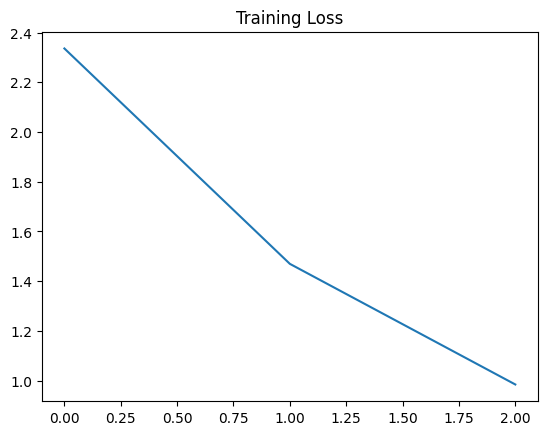

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

epochs = 3
losses = []

for ep in range(epochs):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg = total_loss / len(loader)
    losses.append(avg)
    print(f"Epoch {ep+1}, Loss: {avg:.4f}")

plt.plot(losses)
plt.title("Training Loss")
plt.show()


## 8) Greedy Decoding

Greedy decoding means:

At each step:
- Choose the token with the highest probability (argmax)

This is deterministic and often repetitive,
but simple and easy to understand.


### What generation does

Training supplies the correct target sequence. Generation does not. The model must generate autoregressively:

```text
prompt
  ↓
predict one character
  ↓
append it to the prompt
  ↓
predict the next character
  ↓
repeat
```

`ids[:, -model.seq_len:]` keeps only the most recent 64 characters because that is the model's maximum context length.

`logits[:, -1, :]` selects the prediction at the final position, and `argmax` chooses the highest-scoring character. That is greedy decoding, so the same prompt and model produce the same output.

`torch.no_grad()` disables gradient tracking because generation is inference, not training.

In [9]:
@torch.no_grad()
def generate(prompt, max_new=100):
    model.eval()
    ids = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new):
        ids_cond = ids[:, -model.seq_len:]
        logits = model(ids_cond)
        next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        ids = torch.cat([ids, next_token], dim=1)

    return decode(ids[0].tolist())

print(generate("The moonlight ", 150))


The moonlight she ake.
St soreed t ly t he t she soe breed begenly bre ed iene wone word word athoe at athe.
Sthrd a the thre.
A t t t soft moft moft merered theed 


# Decoding Strategies


## Example

Prompt:
> "I love eating"

Assume the model predicts the following probabilities for the next word:

| Word   | Probability |
|--------|------------|
| pizza  | 0.50       |
| pasta  | 0.30       |
| salad  | 0.10       |
| burger | 0.07       |
| sushi  | 0.03       |

Now we must decide which word to pick.

This is where decoding strategies come in.




## 1. Greedy Decoding

Greedy decoding simply picks the word with the highest probability.

From our example:

- pizza = 0.50 (highest)
- Therefore, choose **"pizza"**

This happens every time.

### Characteristics

- Deterministic (same input → same output)
- No randomness
- Often repetitive
- Safe but not creative

### When is it useful?

- Debugging
- When consistent outputs are required
- When randomness is undesirable


## 2. Temperature Scaling

Temperature controls how "confident" or "creative" the model is.

Before applying softmax, logits are divided by a value called T (temperature).

### Low Temperature (T < 1)

Makes high probabilities even higher.

Example:

| Word   | New Probability (T=0.5) |
|--------|--------------------------|
| pizza  | 0.70                     |
| pasta  | 0.20                     |
| others | very small               |

Effect:
- Model becomes more confident
- More deterministic
- More repetitive



### High Temperature (T > 1)

Flattens the distribution.

Example:

| Word   | New Probability (T=1.5) |
|--------|--------------------------|
| pizza  | 0.35                     |
| pasta  | 0.28                     |
| salad  | 0.15                     |
| burger | 0.12                     |
| sushi  | 0.10                     |

Effect:
- More randomness
- More diversity
- Risk of incoherent output



Important:
Temperature only affects results when **sampling** is used.
It does NOT change greedy decoding.


Low = careful
High = adventurous


## Sampling

Instead of always picking the highest probability word,
we randomly choose according to the probability distribution.

Example:

If:
- pizza = 0.50
- pasta = 0.30

Then:
- 50% of the time → pizza
- 30% of the time → pasta

This introduces diversity into generation.


## 3. Top-k Sampling

Problem:
The vocabulary may contain 50,000+ words.
Even very low-probability words can sometimes be selected when sampling.

Solution:
Only keep the top k most likely words.
Remove all others.



### Example: k = 2

Keep:

| Word  | Probability |
|--------|------------|
| pizza | 0.50       |
| pasta | 0.30       |

Remove:
- salad
- burger
- sushi

Re-normalize probabilities:

| Word  | New Probability |
|--------|----------------|
| pizza | 0.62           |
| pasta | 0.38           |

Now sampling happens only between pizza and pasta.

Effect:
- Still diverse
- Much safer
- Reduces random nonsense


Small k = shortlist
Large k = bigger pool

## Difference between actual Transformer and our mini GPT

| Component               | Original Transformer               | Our Mini-GPT               |
| ----------------------- | ---------------------------------- | --------------------------- |
| Architecture            | Encoder + decoder                  | Decoder only                |
| Tokenization            | Word/subword-oriented              | Character-level             |
| Attention               | Multi-head                         | Single-head                 |
| Number of blocks        | Six encoder and six decoder layers | One decoder block           |
| Position information    | Sinusoidal encoding                | Learned position embeddings |
| Decoder masking         | Yes                                | Yes                         |
| Cross-attention         | Yes                                | No                          |
| Feed-forward activation | ReLU                               | GELU                        |
| Training task           | Translation                        | Next-character prediction   |
| Generation              | Autoregressive                     | Autoregressive              |
| Decoding                | Various possibilities              | Greedy only                 |


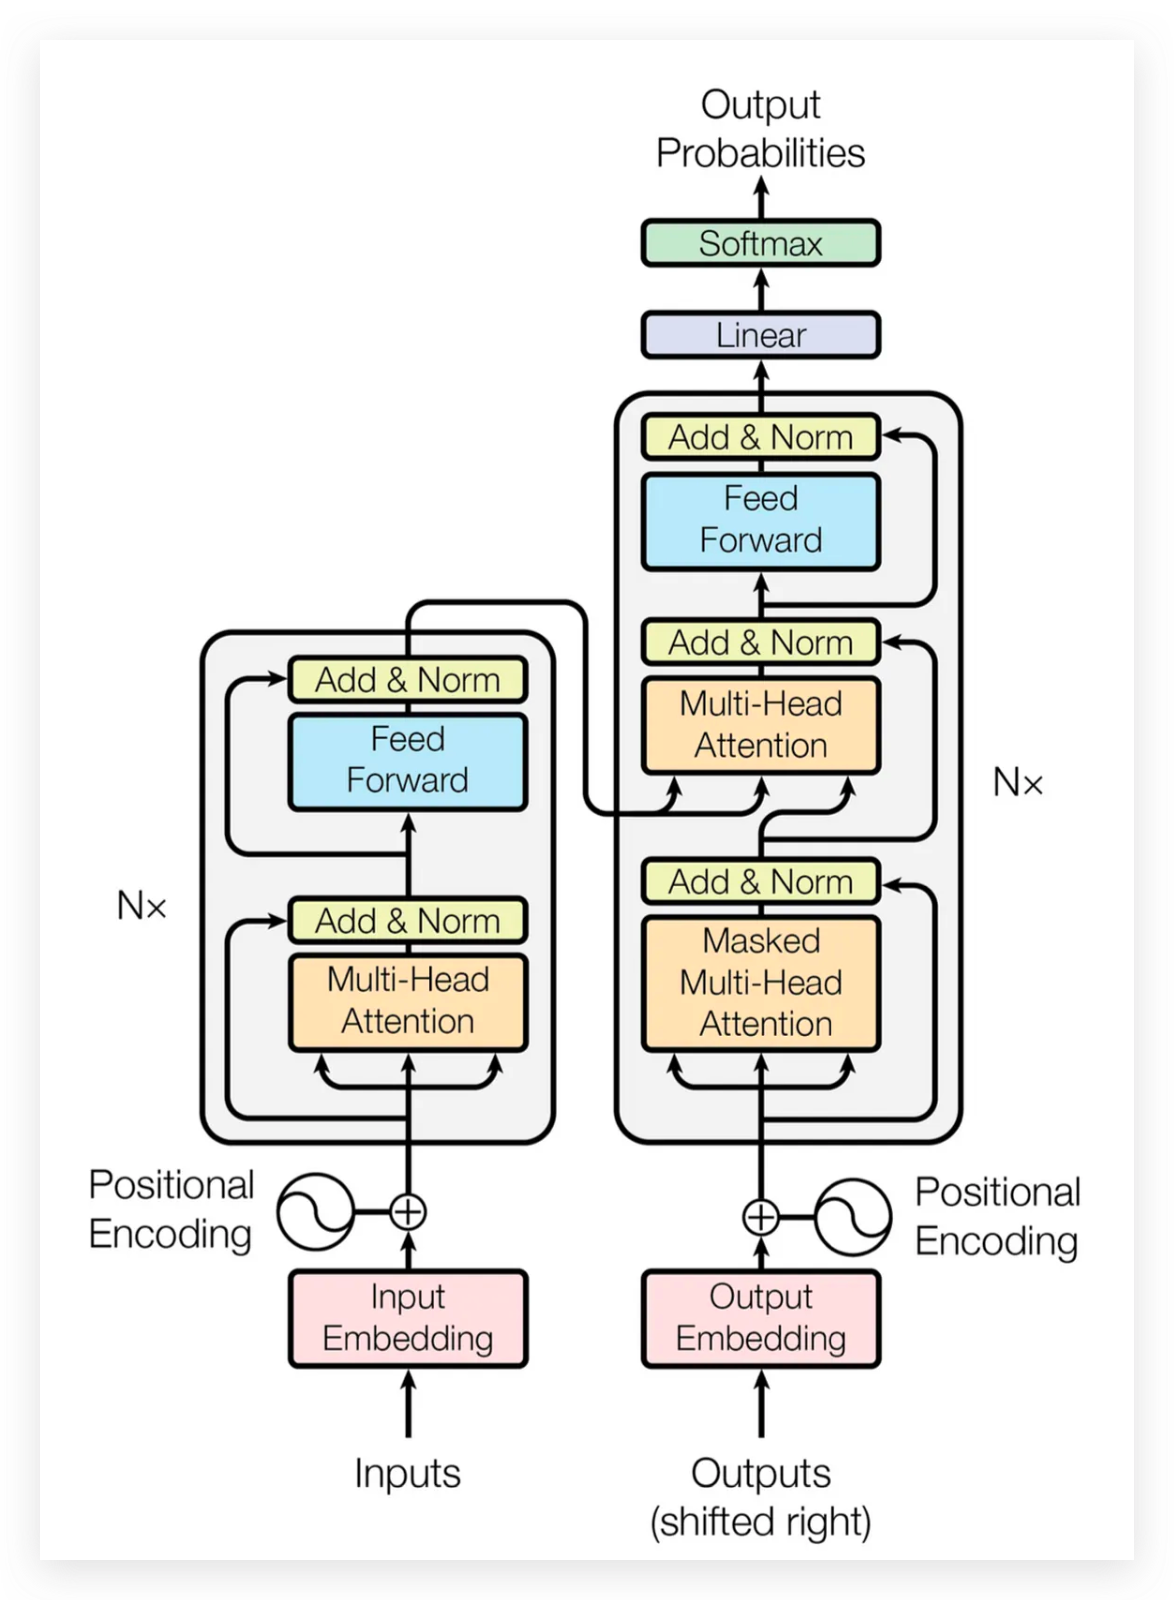